In [1]:
import pandas as pd
#from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')

# Convert 'state' if needed
state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)

# 🔍 Check which columns you’re using
feature_cols = [col for col in df.columns if col not in ['SOH', 'capacity', 'cycle', 'cell', 'T_C','state', 'Zmag_1000Hz','R_sei', 'R_s','Zmag_100Hz','C_dl_est','Zmag_0.1Hz','Zmag_10Hz','R_ct','tail_slope','tail_angle_deg','f_peak_main','Phase_100Hz', 'Phase_0.1Hz','Phase_1000Hz','Phase_10Hz']]  # Adjust as needed
target_col = 'SOH'

In [2]:
train_groups = [(25, 6), (25, 7), (25, 8), (25, 5), (25, 3), (25, 4), (35, 1)]
val_groups   = [(25, 2), (45, 2)]                 # validation cell(s)
test_groups  = [(25, 1), (35, 2), (45, 1)]         # final test cell(s)

In [3]:
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
val_mask   = mask_from_groups(df, val_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
print("Val  :", val_df.shape,   "Groups:", sorted(set(zip(val_df.T_C, val_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))


Train: (1280, 29) Groups: [(25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1)]
Val  : (491, 29) Groups: [(25, 2), (45, 2)]
Test : (966, 29) Groups: [(25, 1), (35, 2), (45, 1)]


In [8]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

features = [
    "R_s_rel",
    "R_ct_rel",
    "Zmag_0.1Hz_rel",
    "C_dl_log",
    "tail_slope"
]

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred)))
    }

X_train, y_train = train_df[features], train_df["SOH"]
X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]


In [9]:
print("NaNs train:", X_train.isna().sum().sum(), "val:", X_val.isna().sum().sum(), "test:", X_test.isna().sum().sum())


NaNs train: 0 val: 0 test: 0


In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbr = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_depth=4,
    max_iter=2000,     # more trees; you can tune this
    random_state=42
)

gbr.fit(X_train, y_train)
print("Gradient Boosting performance")
print("Train:", metrics(y_train, gbr.predict(X_train)))
print("Val  :", metrics(y_val,   gbr.predict(X_val)))
print("Test :", metrics(y_test,  gbr.predict(X_test)))



Gradient Boosting performance
Train: {'R2': 0.9986991488553708, 'MAE': 0.0048212775141232445, 'RMSE': 0.0071474212423270015}
Val  : {'R2': -0.24960734372044735, 'MAE': 0.07039131685709407, 'RMSE': 0.079891048117553}
Test : {'R2': 0.8161295091295457, 'MAE': 0.06288591381073383, 'RMSE': 0.07785674486071228}


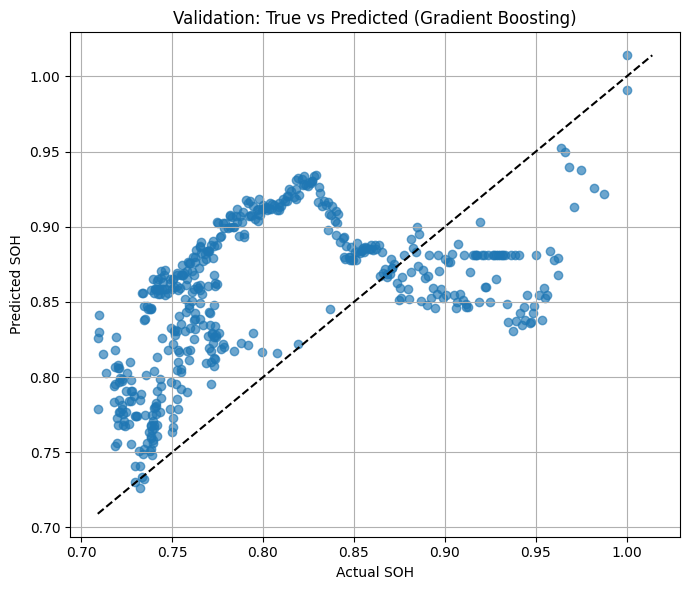

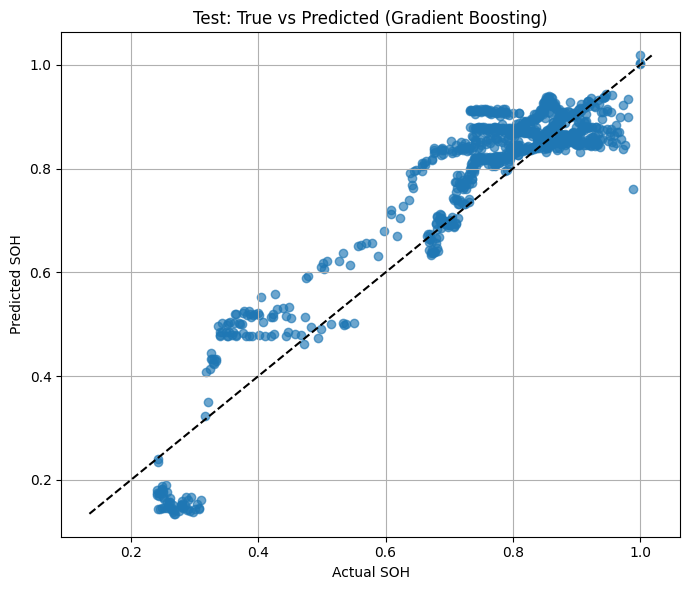

In [11]:
import matplotlib.pyplot as plt

def true_vs_pred_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(7,6))
    plt.scatter(y_true, y_pred, alpha=0.65)
    plt.plot([lo, hi], [lo, hi], "k--")
    plt.xlabel("Actual SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

true_vs_pred_plot(y_val,  gbr.predict(X_val),  "Validation: True vs Predicted (Gradient Boosting)")
true_vs_pred_plot(y_test, gbr.predict(X_test), "Test: True vs Predicted (Gradient Boosting)")


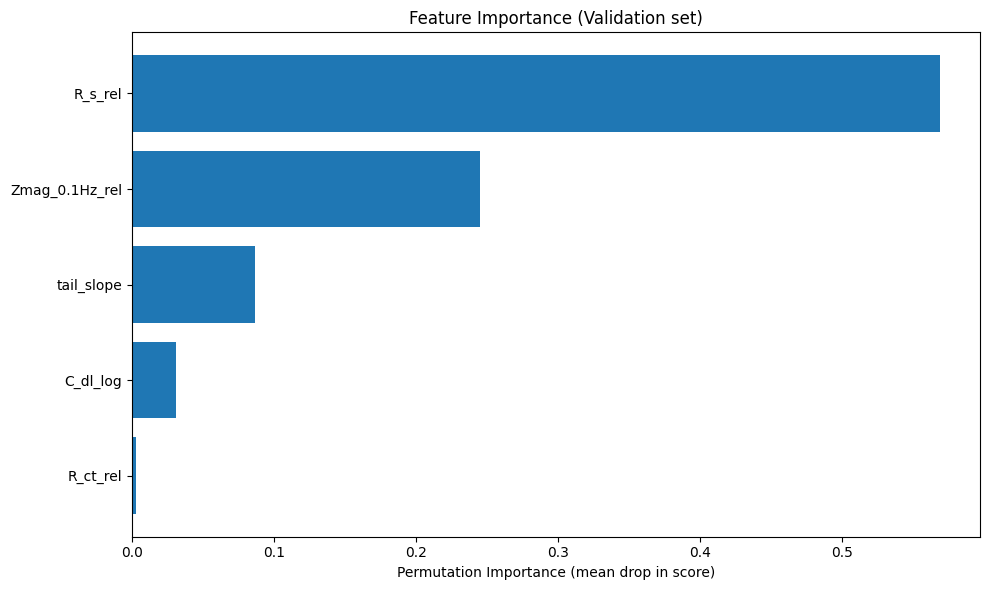

In [14]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_val, y_val, n_repeats=30, random_state=42, n_jobs=-1)
imp = pd.DataFrame({"feature": features, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
imp = imp.sort_values("importance_mean", ascending=False)
imp

plt.figure(figsize=(10,6))
plt.barh(imp["feature"], imp["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (mean drop in score)")
plt.title("Feature Importance (Validation set)")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error

grid = []
best = None
best_rmse = np.inf

for max_depth in [2, 3, 4, 5, 6]:
    for lr in [0.01, 0.03, 0.05, 0.1]:
        for max_iter in [500, 1000, 2000, 4000]:
            model = HistGradientBoostingRegressor(
                learning_rate=lr,
                max_depth=max_depth,
                max_iter=max_iter,
                random_state=42
            )
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

            grid.append({"max_depth": max_depth, "learning_rate": lr, "max_iter": max_iter, "val_rmse": rmse})

            if rmse < best_rmse:
                best_rmse = rmse
                best = model
                best_params = {"max_depth": max_depth, "learning_rate": lr, "max_iter": max_iter}

grid_df = pd.DataFrame(grid).sort_values("val_rmse")
print("Best params:", best_params, "Best Val RMSE:", best_rmse)
grid_df.head(10)


KeyboardInterrupt: 

In [ ]:
print("BEST Gradient Boosting performance")
print("Train:", metrics(y_train, best.predict(X_train)))
print("Val  :", metrics(y_val,   best.predict(X_val)))
print("Test :", metrics(y_test,  best.predict(X_test)))


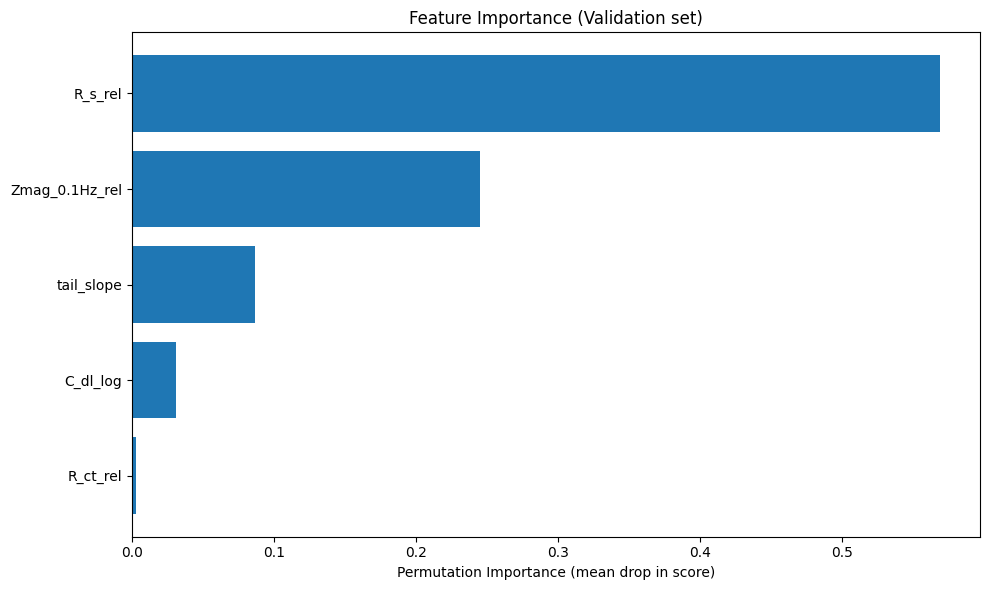

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_val, y_val, n_repeats=30, random_state=42, n_jobs=-1)
imp = pd.DataFrame({"feature": features, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
imp = imp.sort_values("importance_mean", ascending=False)
imp

plt.figure(figsize=(10,6))
plt.barh(imp["feature"], imp["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (mean drop in score)")
plt.title("Feature Importance (Validation set)")
plt.tight_layout()
plt.show()
